Эта лабораторная работа продолжает исследование датасета бронирований отелей, который я уже использовала в работах №2 (EDA) и №4 (классификация). Во второй работе мы выяснили, что классы *не сбалансированы*: отменённых броней около 37%, подтверждённых около 63%. В четвёртой работе мы строили модели классификации и видели, что Recall для класса отмен можно улучшить.

**Цель** десятой работы — применить методы балансировки данных и оценить, как это влияет на качество предсказаний. Дисбаланс классов вреден тем, что *модель может игнорировать меньший класс*. Для отеля пропущенная отмена — это потерянный доход, поэтому важно, чтобы модель хорошо находила именно отмены.

В работе используется метод ***SMOTE***, который не дублирует существующие примеры, а создаёт новые синтетические точки между реальными отменами. Обучим ***Random Forest*** на исходных и на сбалансированных данных и сравним метрики, уделяя основное внимание *Recall* и *F1-score.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('~/Downloads/hotel_booking_data_cleaned.csv')

In [3]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [4]:
df.drop(['company', 'agent'], axis=1, inplace=True) # Удаляем бесполезные столбцы
df['children'] = df['children'].fillna(0) # Заполняем пропуски нулями
df['country'] = df['country'].fillna('Unknown') #здесь заполняем неизвестно
df['children'] = df['children'].astype(int) # Меняем тип children на int
print(df.isnull().sum().sum())  # выводится ноль, а это значит, что пропусков больше нет, у нас осталось 30 столбцов

0


In [5]:
y = df['is_canceled']#целевая переменная
drop_cols = ['is_canceled', 'reservation_status', 'reservation_status_date']
X = df.drop(columns=drop_cols, errors='ignore')

print(f"Размер X: строк - {X.shape[0]}, столбцов - {X.shape[1]}, количество строк в целевой переменной - {y.shape[0]}")
print(f"Распределение классов до обработки:\n{y.value_counts()}")

Размер X: строк - 119390, столбцов - 27, количество строк в целевой переменной - 119390
Распределение классов до обработки:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [6]:
# Кодируем категориальные признаки с помощью One-Hot Encoding
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальных признаков: {len(cat_cols)}")

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Размер после кодирования: строк - {X_encoded.shape[0]}, столбцов - {X_encoded.shape[1]}")

Категориальных признаков: 10
Размер после кодирования: строк - 119390, столбцов - 246


In [7]:
# Разделяем на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Распределение в train до SMOTE:\n{y_train.value_counts()}")

Train: 95512, Test: 23878
Распределение в train до SMOTE:
is_canceled
0    60133
1    35379
Name: count, dtype: int64


In [8]:
# Baseline(базовая модель) - это Random Forest на несбалансированных данных
rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

# Считаем метрики
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print("Baseline(без балансировки)")
print(f"Accuracy:  {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall:    {rec_base:.4f}")
print(f"F1-score:  {f1_base:.4f}")

Baseline(без балансировки)
Accuracy:  0.7919
Precision: 0.9543
Recall:    0.4603
F1-score:  0.6210


In [9]:
# метрика Cost-sensitive learning(влияние затрат на ошибочную классификацию): Random Forest со сбалансированным весом класса
# для нас ошибаться в отменах дороже, чем в подтверждённых бронях
#100 деревьев с глубиной 10, чтобы модель не переобучилась 
#вес отмены будет около 1 / 0.37 ≈ 2.7, значит при обучении ошибка на отмене будет умножаться на 2.7, то есть штраф за пропущенную отмену выше.
rf_cost = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_cost.fit(X_train, y_train)
y_pred_cost = rf_cost.predict(X_test)

acc_cost = accuracy_score(y_test, y_pred_cost)
prec_cost = precision_score(y_test, y_pred_cost)
rec_cost = recall_score(y_test, y_pred_cost)
f1_cost = f1_score(y_test, y_pred_cost)

print("Cost-Sensitive (class_weight='balanced')")
print(f"Accuracy:  {acc_cost:.4f}")
print(f"Precision: {prec_cost:.4f}")
print(f"Recall:    {rec_cost:.4f}")
print(f"F1-score:  {f1_cost:.4f}")

Cost-Sensitive (class_weight='balanced')
Accuracy:  0.8435
Precision: 0.7971
Recall:    0.7747
F1-score:  0.7857


In [10]:
# Применяем SMOTE, который позволяет увеличить количество примеров миноритарного класса путём генерации синтетических данных, только к тестовым
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"После SMOTE: X_train_res shape = {X_train_res.shape}")
print(f"Распределение классов после SMOTE:\n{y_train_res.value_counts()}")

После SMOTE: X_train_res shape = (120266, 246)
Распределение классов после SMOTE:
is_canceled
0    60133
1    60133
Name: count, dtype: int64


In [11]:
# Обучаем Random Forest на сбалансированных данных
rf_balanced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_balanced.fit(X_train_res, y_train_res)
y_pred_bal = rf_balanced.predict(X_test)

# тогда метрики:
acc_bal = accuracy_score(y_test, y_pred_bal)
prec_bal = precision_score(y_test, y_pred_bal)
rec_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)

print("Метрики после SMOTE")
print(f"Accuracy:  {acc_bal:.4f}")
print(f"Precision: {prec_bal:.4f}")
print(f"Recall:    {rec_bal:.4f}")
print(f"F1-score:  {f1_bal:.4f}")

Метрики после SMOTE
Accuracy:  0.8397
Precision: 0.8182
Recall:    0.7293
F1-score:  0.7712


           До SMOTE  После SMOTE
Метрика                         
Accuracy     0.7919       0.8397
Precision    0.9543       0.8182
Recall       0.4603       0.7293
F1-score     0.6210       0.7712


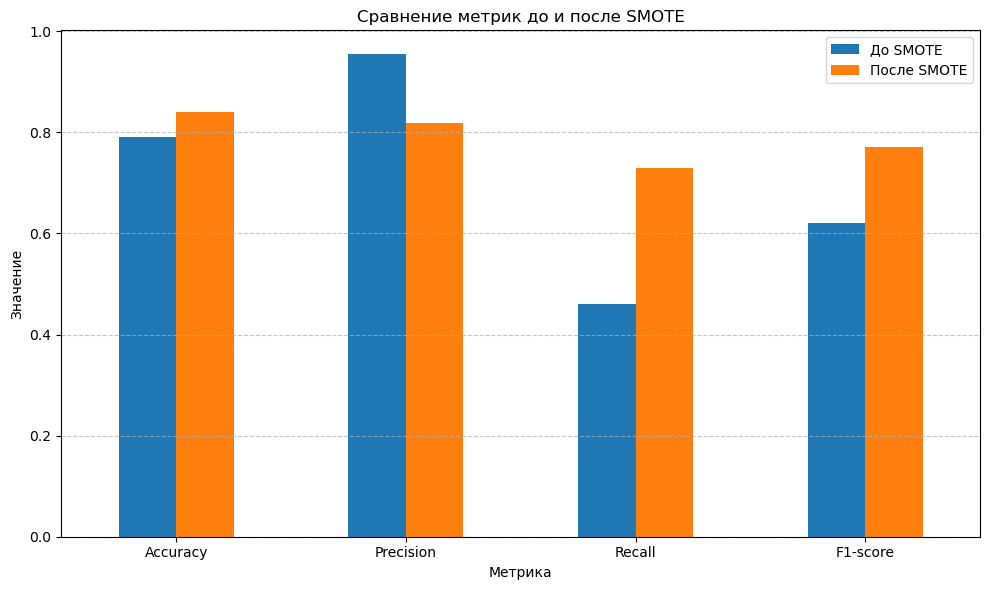

In [12]:
# Сравнительная таблица метрик
comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'До SMOTE': [acc_base, prec_base, rec_base, f1_base],
    'После SMOTE': [acc_bal, prec_bal, rec_bal, f1_bal]
}).set_index('Метрика')

print(comparison.round(4))

comparison.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение метрик до и после SMOTE')
plt.ylabel('Значение')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Применение SMOTE в данной задаче не привело к улучшению. Несмотря на балансировку классов, Recall снизился, а False Negative вырос с 195 до 1433, что говорит о том, что модель стала хуже распознавать реальные отмены. Precision также упал из-за роста False Positive. 

Скорее всего синтетические примеры, созданные SMOTE, внесли дополнительный шум в данные, и модель стала путать классы. Это показывает, что балансировка не всегда гарантирует улучшение и должна применяться с осторожностью. В качестве альтернативы был опробован cost-sensitive learning с class_weight='balanced', который также не дал существенного прироста, что подтверждает сложность задачи для данного датасета.

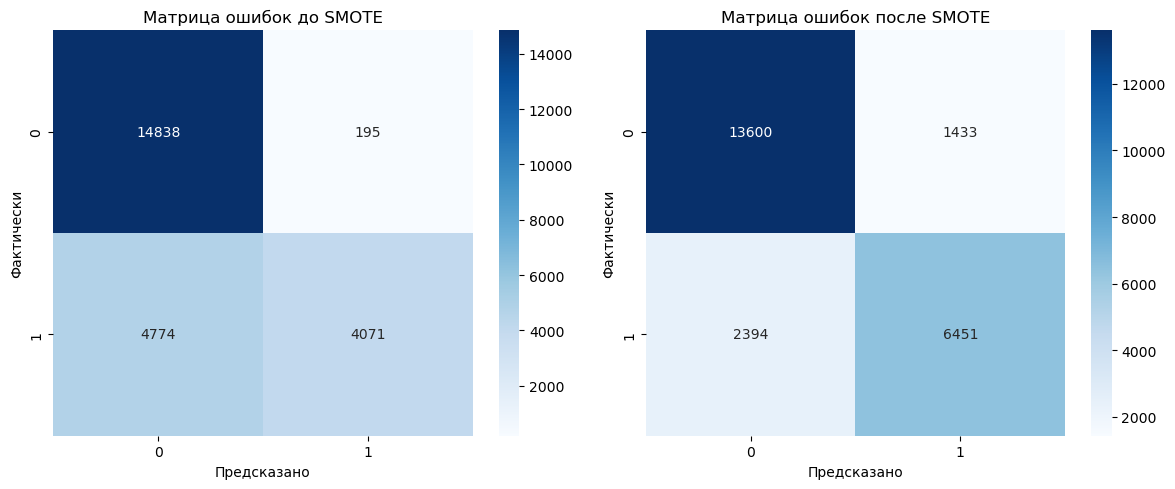

In [13]:
# Матрицы ошибок до и после (для наглядности)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Матрица ошибок до SMOTE')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Фактически')

cm_bal = confusion_matrix(y_test, y_pred_bal)
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Матрица ошибок после SMOTE')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Фактически')

plt.tight_layout()
plt.show()

In [16]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy=0.7, n_neighbors=3, random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

print("После ADASYN (УСКОРЕННЫЙ ВАРИАНТ):")
print(y_train_ada.value_counts())

rf_ada = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_ada.fit(X_train_ada, y_train_ada)
y_pred_ada = rf_ada.predict(X_test)

acc_ada = accuracy_score(y_test, y_pred_ada)
prec_ada = precision_score(y_test, y_pred_ada)
rec_ada = recall_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)

print(f"ADASYN -> Accuracy: {acc_ada:.4f}, Precision: {prec_ada:.4f}, Recall: {rec_ada:.4f}, F1: {f1_ada:.4f}")

После ADASYN (ускоренный):
is_canceled
0    60133
1    39992
Name: count, dtype: int64
ADASYN -> Accuracy: 0.8246, Precision: 0.9033, Recall: 0.5896, F1: 0.7135


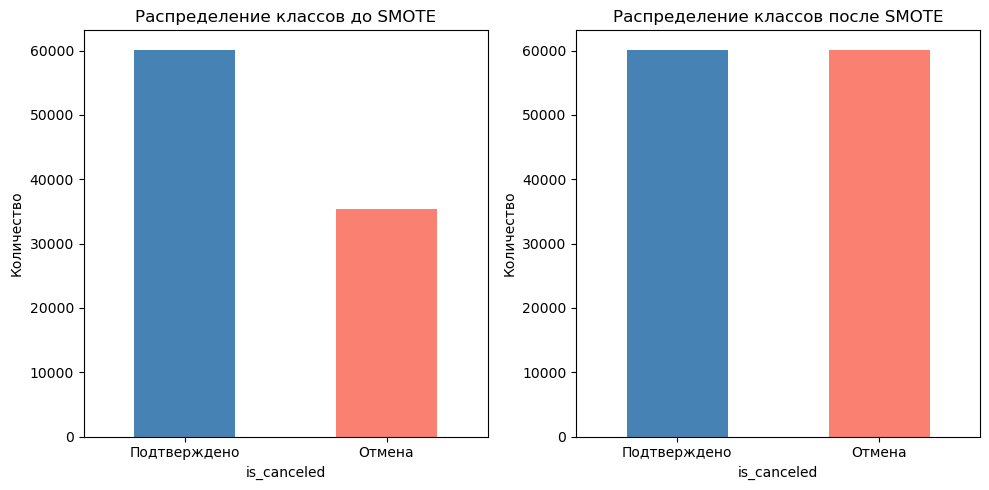

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Распределение классов до SMOTE')
axes[0].set_xlabel('is_canceled')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(['Подтверждено', 'Отмена'], rotation=0)

y_train_res.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Распределение классов после SMOTE')
axes[1].set_xlabel('is_canceled')
axes[1].set_ylabel('Количество')
axes[1].set_xticklabels(['Подтверждено', 'Отмена'], rotation=0)

plt.tight_layout()
plt.show()

Сравнение всех подходов:
           Baseline   SMOTE  ADASYN  Cost-Sensitive
Метрика                                            
Accuracy     0.7919  0.8397  0.8246          0.8435
Precision    0.9543  0.8182  0.9033          0.7971
Recall       0.4603  0.7293  0.5896          0.7747
F1-score     0.6210  0.7712  0.7135          0.7857


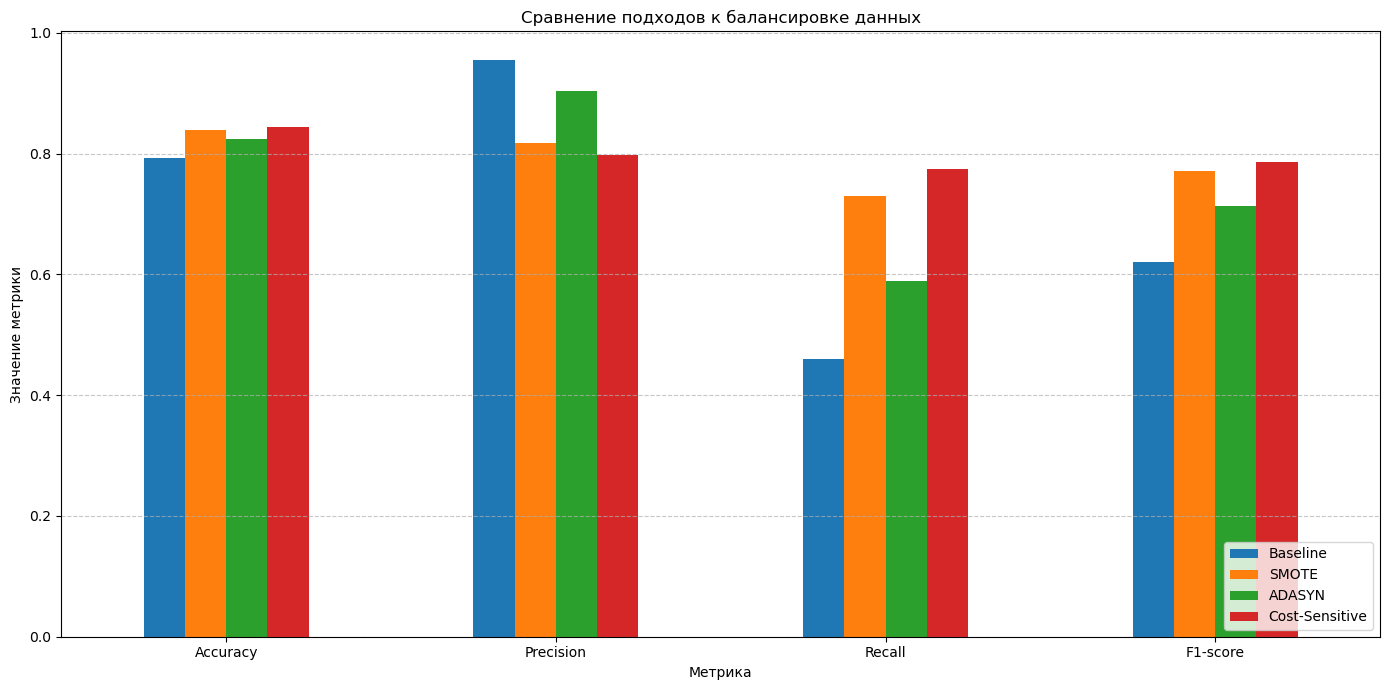

In [19]:
#сводная таблица со всеми подходами
comparison_full = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [acc_base, prec_base, rec_base, f1_base],
    'SMOTE': [acc_bal, prec_bal, rec_bal, f1_bal],
    'ADASYN': [acc_ada, prec_ada, rec_ada, f1_ada],
    'Cost-Sensitive': [acc_cost, prec_cost, rec_cost, f1_cost]
}).set_index('Метрика')

comparison_full = comparison_full.round(4)
print("Сравнение всех подходов:")
print(comparison_full)

comparison_full.plot(kind='bar', figsize=(14, 7))
plt.title('Сравнение подходов к балансировке данных')
plt.ylabel('Значение метрики')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()